In [1]:
!pip install roboflow timm einops ultralytics pyyaml


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 46.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 71.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency

# **1.Install & Imports**

In [2]:
import os
import yaml
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image

from timm.models.vision_transformer import PatchEmbed, Block
from einops import rearrange
from tqdm import tqdm
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# **2.Setup**

In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="J1rWUvuwvKwOyLI5ooEK")
project = rf.workspace("sanjana-kazi-supti-ymhu2").project("non-seasonal-vegetable-detection-yms0u")
version = project.version(3)
dataset = version.download("yolov12")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Non-Seasonal-Vegetable-Detection-3 in yolov12:: 100%|██████████| 9606/9606 [00:00<00:00, 10315.96it/s]


In [4]:
ROOT = dataset.location
DATA_YAML = f"{ROOT}/data.yaml"


In [5]:

DATASET_PATH = os.path.join(
    dataset.location,
    "train/images"
)

IMG_SIZE = 640

transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])


class SSLDataset(Dataset):

    def __init__(self, image_dir, transform=None):

        self.image_dir = image_dir
        self.transform = transform

        self.images = [
            os.path.join(image_dir, x)
            for x in os.listdir(image_dir)
            if x.endswith((".jpg", ".png", ".jpeg"))
        ]

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        img_path = self.images[idx]

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, 0


train_dataset = SSLDataset(
    image_dir=DATASET_PATH,
    transform=transform
)

print(f"Total Images: {len(train_dataset)}")


train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

print("train_loader ready")


Total Images: 3359
train_loader ready


# **3.MAE Dataset**

In [6]:
class UnlabeledImageDataset(Dataset):
    def __init__(self, img_dir, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.images = [f for f in os.listdir(img_dir) if f.endswith(".jpg")]

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = Image.open(
            os.path.join(self.img_dir, self.images[idx])
        ).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img


In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

mae_dataset = UnlabeledImageDataset(
    img_dir=f"{ROOT}/train/images",
    transform=transform
)

mae_loader = DataLoader(
    mae_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=2
)

print("Total unlabeled images:", len(mae_dataset))


Total unlabeled images: 3359


# **4.CNN-Compatible MAE-Style SSL MODEL**

In [8]:

class RandomMasking:
    def __init__(self, mask_ratio=0.6, patch_size=16):
        self.mask_ratio = mask_ratio
        self.patch_size = patch_size

    def __call__(self, img):
        _, H, W = img.shape

        h = H // self.patch_size
        w = W // self.patch_size

        total = h * w
        num_mask = int(total * self.mask_ratio)

        mask = torch.zeros(total)
        idx = torch.randperm(total)[:num_mask]
        mask[idx] = 1

        mask = mask.reshape(h, w)

        return mask


def apply_mask(img, mask, patch_size=16):
    img = img.clone()

    h, w = mask.shape

    for i in range(h):
        for j in range(w):

            if mask[i, j] == 1:

                y1 = i * patch_size
                y2 = y1 + patch_size

                x1 = j * patch_size
                x2 = x1 + patch_size

                img[:, y1:y2, x1:x2] = 0

    return img


class ReconstructionDecoder(nn.Module):

    def __init__(self, in_channels=256):

        super().__init__()

        self.decoder = nn.Sequential(

            nn.ConvTranspose2d(in_channels, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(128, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),

            nn.ConvTranspose2d(64, 32, 4, 2, 1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):

        return self.decoder(x)


yolo_ssl = YOLO("yolo12s.pt")

full_model = yolo_ssl.model

backbone = full_model.model[:10]

class YOLO_MAE_SSL(nn.Module):

    def __init__(self, backbone, decoder):

        super().__init__()

        self.backbone = backbone
        self.decoder = decoder

    def forward(self, x):

        for layer in self.backbone:
            x = layer(x)

        reconstruction = self.decoder(x)

        return reconstruction


# **5.CNN-Compatible SSL PRETRAINING**

In [9]:

device = "cuda" if torch.cuda.is_available() else "cpu"

backbone = backbone.to(device)

sample = torch.randn(1, 3, 640, 640).to(device)

x = sample

for i, layer in enumerate(backbone):
    x = layer(x)
    print(f"Layer {i}: {x.shape}")

decoder = ReconstructionDecoder(in_channels=x.shape[1]).to(device)

ssl_model = YOLO_MAE_SSL(backbone, decoder).to(device)

criterion = nn.MSELoss()

optimizer = torch.optim.AdamW(
    ssl_model.parameters(),
    lr=5e-4,
    weight_decay=0.05  
)

masking = RandomMasking(mask_ratio=0.6)


Layer 0: torch.Size([1, 32, 320, 320])
Layer 1: torch.Size([1, 64, 160, 160])
Layer 2: torch.Size([1, 128, 160, 160])
Layer 3: torch.Size([1, 128, 80, 80])
Layer 4: torch.Size([1, 256, 80, 80])
Layer 5: torch.Size([1, 256, 40, 40])
Layer 6: torch.Size([1, 256, 40, 40])
Layer 7: torch.Size([1, 512, 20, 20])
Layer 8: torch.Size([1, 512, 20, 20])
Layer 9: torch.Size([1, 512, 40, 40])


In [10]:

scaler = torch.cuda.amp.GradScaler(enabled=(device == "cuda"))

CHECKPOINT_EVERY = 10
num_epochs = 50

ssl_model.train()

for epoch in range(num_epochs):

    total_loss = 0

    loop = tqdm(train_loader)

    for images, _ in loop:

        images = images.to(device)

        masked_images = []

        for img in images:

            mask = masking(img)

            masked_img = apply_mask(img, mask)

            masked_images.append(masked_img)

        masked_images = torch.stack(masked_images).to(device)

        optimizer.zero_grad()

        with torch.cuda.amp.autocast(enabled=(device == "cuda")):

            outputs = ssl_model(masked_images)

            outputs = F.interpolate(
                outputs,
                size=images.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(outputs, images)

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        total_loss += loss.item()

        loop.set_description(f"Epoch {epoch+1}")

        loop.set_postfix(loss=loss.item())

    avg_loss = total_loss / len(train_loader)

    print(f"Epoch {epoch+1}: {avg_loss:.4f}")

    if (epoch + 1) % CHECKPOINT_EVERY == 0:

        torch.save(
            ssl_model.state_dict(),
            f"ssl_checkpoint_epoch_{epoch+1}.pth"
        )


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
Epoch 1: 100%|██████████| 53/53 [02:41<00:00,  3.05s/it, loss=0.0146]


Epoch 1: 0.0294


Epoch 2: 100%|██████████| 53/53 [02:34<00:00,  2.92s/it, loss=0.0114]


Epoch 2: 0.0142


Epoch 3: 100%|██████████| 53/53 [02:35<00:00,  2.94s/it, loss=0.0119]


...

Epoch 48: 0.0093


Epoch 49: 100%|██████████| 53/53 [02:36<00:00,  2.96s/it, loss=0.00829]


Epoch 49: 0.0093


Epoch 50: 100%|██████████| 53/53 [02:36<00:00,  2.95s/it, loss=0.00955]

Epoch 50: 0.0092


## **SAVE SSL PRETRAINED YOLO BACKBONE**

In [11]:

torch.save(
    backbone.state_dict(),
    "ssl_yolo_backbone.pth"
)
print("SSL pretrained YOLO backbone saved.")

# Also save the full ssl_model so Section 6 can reload it for feature extraction
torch.save(
    ssl_model.state_dict(),
    "mae_pretrained_encoder.pth"
)
print("Full SSL model saved as mae_pretrained_encoder.pth")


SSL pretrained YOLO backbone saved.
Full SSL model saved as mae_pretrained_encoder.pth


# **6. Feature Extraction Plot (K-NN, PCA, t-SNE, UMAP)**

E0000 00:00:1778861914.141763      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778861914.197073      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778861914.636839      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778861914.636869      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778861914.636872      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778861914.636874      23 computation_placer.cc:177] computation placer already registered. Please check linka

➤ Rebuilding YOLO_MAE_SSL architecture for feature extraction …
➤ Loading pretrained SSL weights from mae_pretrained_encoder.pth …
➤ CNN feature extractor ready.
➤ Extracting features …



MAE k-NN evaluation …
k-NN accuracy (val): 0.8757


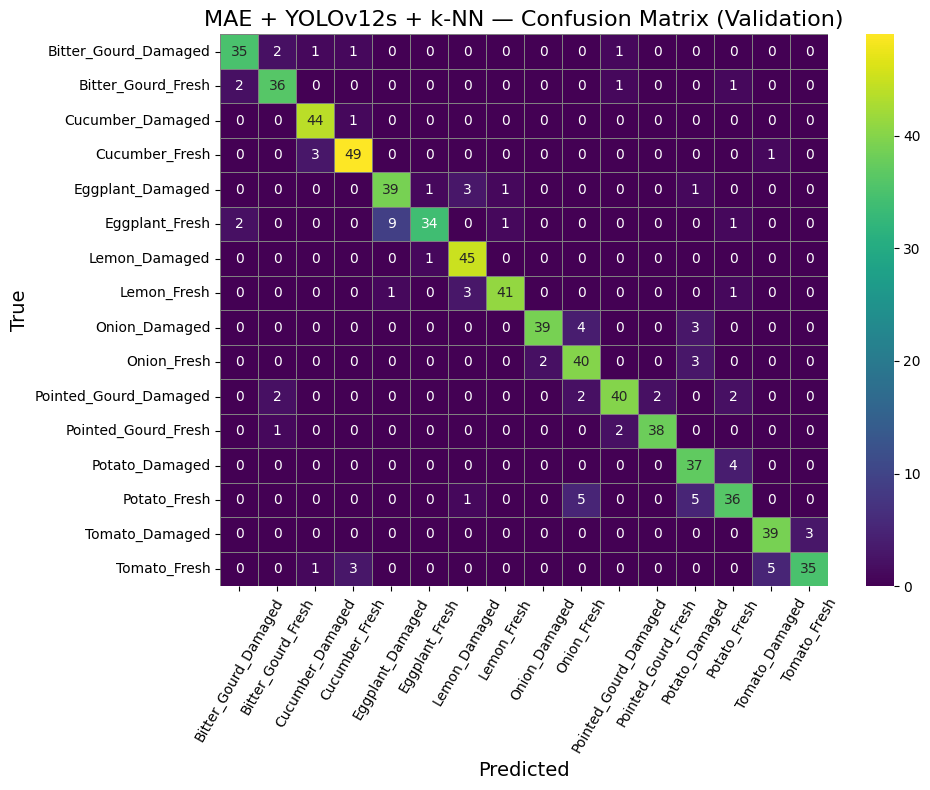

➤ Running PCA …
PCA 2D explained variance: 19.81%


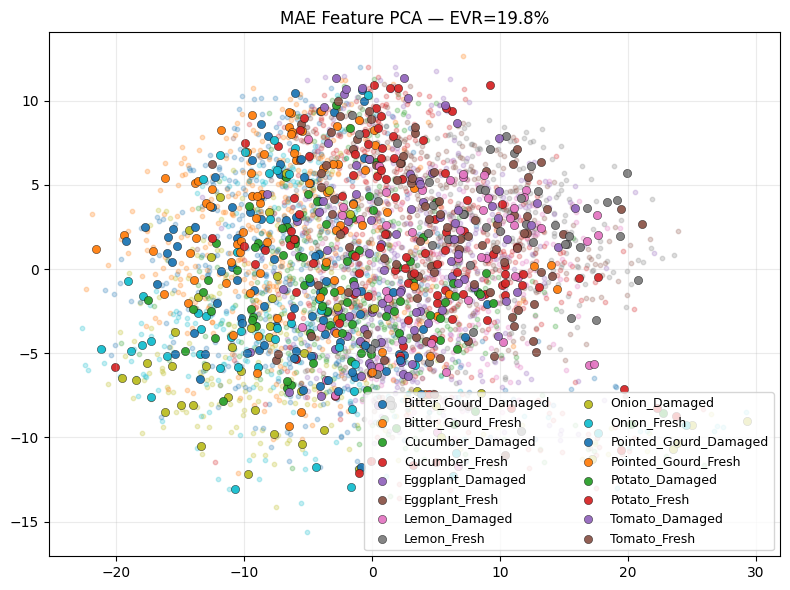

➤ Running t-SNE …


'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.


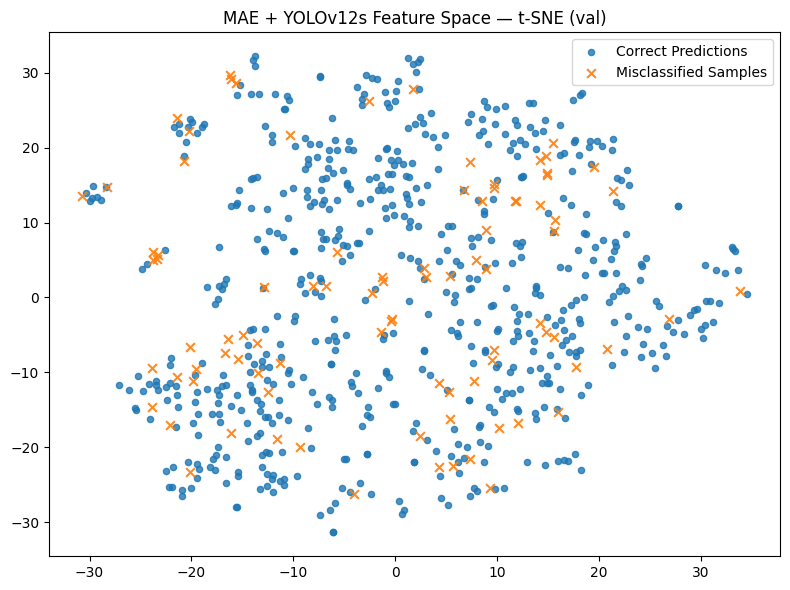

➤ Running UMAP …


n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.


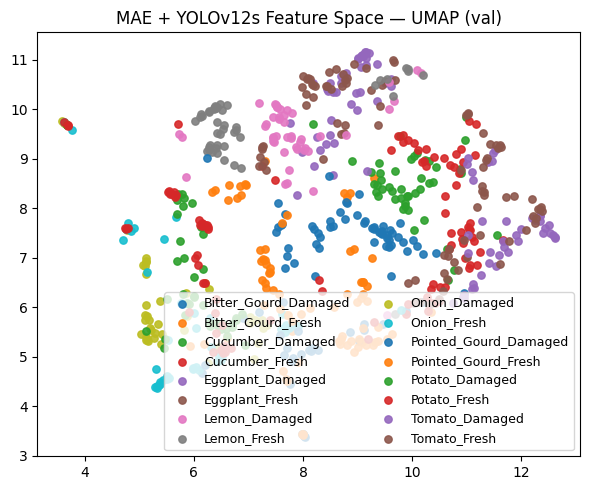


✓ All visualizations saved in: runs/detect/mae_yolov12s_detector/plots


In [12]:
import os, gc, torch, umap, numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from PIL import Image
from tqdm import tqdm
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# -----------------------------------------
# CONFIG
# -----------------------------------------
WORK_FEAT = Path("runs/detect/mae_yolov12s_detector")
PLOTS = WORK_FEAT / "plots"
PLOTS.mkdir(parents=True, exist_ok=True)

class_names = [
    "Bitter_Gourd_Damaged",
    "Bitter_Gourd_Fresh",
    "Cucumber_Damaged",
    "Cucumber_Fresh",
    "Eggplant_Damaged",
    "Eggplant_Fresh",
    "Lemon_Damaged",
    "Lemon_Fresh",
    "Onion_Damaged",
    "Onion_Fresh",
    "Pointed_Gourd_Damaged",
    "Pointed_Gourd_Fresh",
    "Potato_Damaged",
    "Potato_Fresh",
    "Tomato_Damaged",
    "Tomato_Fresh"
]

# -----------------------------------------
# HELPERS
# -----------------------------------------
def imread_rgb(path: Path):
    return Image.open(path).convert("RGB")

def yolo_label_for_image(label_file: Path):
    if not label_file.exists():
        return None
    ids = []
    with open(label_file) as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                try: ids.append(int(parts[0]))
                except: pass
    return max(ids, key=ids.count) if ids else None

def list_images_and_labels(split_dir: Path):
    xs, ys = [], []
    images = sorted((split_dir / "images").glob("*.*"))
    for img_path in images:
        lb_path = split_dir / "labels" / (img_path.stem + ".txt")
        lab = yolo_label_for_image(lb_path)
        if lab is None:
            continue
        xs.append(img_path); ys.append(lab)
    return xs, np.array(ys, dtype=np.int64)

# -----------------------------------------
# CNN BACKBONE ENCODER — reload from saved weights
# (YOLO_MAE_SSL uses a CNN backbone, not a ViT)
# -----------------------------------------

print("➤ Rebuilding YOLO_MAE_SSL architecture for feature extraction …")

# Rebuild the same backbone/decoder used during pretraining
_yolo_for_feat = YOLO("yolo12s.pt")
_backbone_feat  = _yolo_for_feat.model.model[:10].to(device)

# Probe backbone output channels
with torch.no_grad():
    _probe = torch.randn(1, 3, 640, 640).to(device)
    _x = _probe
    for _layer in _backbone_feat:
        _x = _layer(_x)
    _feat_channels = _x.shape[1]

_decoder_feat   = ReconstructionDecoder(in_channels=_feat_channels).to(device)
_ssl_model_feat = YOLO_MAE_SSL(_backbone_feat, _decoder_feat).to(device)

print("➤ Loading pretrained SSL weights from mae_pretrained_encoder.pth …")
_ssl_model_feat.load_state_dict(
    torch.load("mae_pretrained_encoder.pth", map_location=device)
)
_ssl_model_feat.eval()

# Feature extractor: backbone → global avg pool → L2-normalised vector
_feat_backbone = _ssl_model_feat.backbone

def feat_model(x):
    """Extract a flat, L2-normalised feature vector from the pretrained CNN backbone."""
    with torch.no_grad():
        for layer in _feat_backbone:
            x = layer(x)
        x = F.adaptive_avg_pool2d(x, 1).flatten(1)  # [B, C]
        x = F.normalize(x, dim=1)
    return x

print("➤ CNN feature extractor ready.")

# -----------------------------------------
# DATA
# -----------------------------------------
data_root = Path(ROOT)
train_X, train_y = list_images_and_labels(data_root / "train")
val_X,   val_y   = list_images_and_labels(data_root / "valid")
assert len(train_X) and len(val_X), "No labeled images found."

# -----------------------------------------
# FEATURE EXTRACTION
# -----------------------------------------
base_tfm = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

class ImgDataset(Dataset):
    def __init__(self, paths, tfm): self.paths = paths; self.tfm = tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i): return self.tfm(imread_rgb(self.paths[i]))

def extract_feats(paths, bs=64, desc="Extract"):
    ds  = ImgDataset(paths, base_tfm)
    dl  = DataLoader(ds, batch_size=bs, shuffle=False, num_workers=0, pin_memory=False)
    feats = []
    for xb in tqdm(dl, total=len(dl), desc=desc, leave=False):
        xb = xb.to(device, non_blocking=True)
        with torch.no_grad():
            h = feat_model(xb)
            h = F.normalize(h, dim=1)
        feats.append(h.detach().cpu().numpy())
    return np.concatenate(feats, axis=0) if feats else np.zeros((0, 1))

print("➤ Extracting features …")
train_F = extract_feats(train_X, bs=64, desc="Extract train")
val_F   = extract_feats(val_X,   bs=64, desc="Extract val")

gc.collect()
if device == "cuda":
    torch.cuda.empty_cache()

# -----------------------------------------
# k-NN CLASSIFIER
# -----------------------------------------
print("\nMAE k-NN evaluation …")
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(train_F, train_y)

val_pred = knn.predict(val_F)
acc = accuracy_score(val_y, val_pred)
print(f"k-NN accuracy (val): {acc:.4f}")

# -----------------------------------------
# CONFUSION MATRIX — BEAUTIFUL VERSION
# -----------------------------------------
cm = confusion_matrix(val_y, val_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names,
    linewidths=0.5,
    linecolor="gray"
)
plt.title("MAE + YOLOv12s + k-NN — Confusion Matrix (Validation)", fontsize=16)
plt.xlabel("Predicted", fontsize=14)
plt.ylabel("True", fontsize=14)
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(PLOTS / "knn_confusion_matrix.png", dpi=200)
plt.show()

# -----------------------------------------
# STANDARDIZE
# -----------------------------------------
scaler   = StandardScaler()
train_Fs = scaler.fit_transform(train_F)
val_Fs   = scaler.transform(val_F)

# -----------------------------------------
# PCA VISUALIZATION
# -----------------------------------------
print("➤ Running PCA …")
pca     = PCA(n_components=2, random_state=42)
train_P = pca.fit_transform(train_Fs)
val_P   = pca.transform(val_Fs)
evr     = pca.explained_variance_ratio_.sum()
print(f"PCA 2D explained variance: {evr*100:.2f}%")

plt.figure(figsize=(8, 6))
cmap_tab = plt.get_cmap("tab10")

classes = np.unique(np.concatenate([train_y, val_y]))

for c in classes:
    idx = np.where(train_y == c)[0]
    if len(idx):
        plt.scatter(train_P[idx, 0], train_P[idx, 1], s=10, alpha=0.25, color=cmap_tab(c % 10))

for c in classes:
    idx = np.where(val_y == c)[0]
    if len(idx):
        plt.scatter(
            val_P[idx, 0], val_P[idx, 1],
            s=35, alpha=0.95,
            edgecolors="k", linewidths=0.3,
            color=cmap_tab(c % 10),
            label=class_names[c]
        )

plt.title(f"MAE Feature PCA — EVR={evr*100:.1f}%")
plt.legend(fontsize=9, ncol=2)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(PLOTS / "pca_train_val.png", dpi=200)
plt.show()

# -----------------------------------------
# t-SNE
# -----------------------------------------
if len(val_F) > 10:
    print("➤ Running t-SNE …")
    perplex = min(30, max(5, len(val_F) // 10))
    tsne = TSNE(n_components=2, init="pca", learning_rate="auto",
                perplexity=perplex, n_iter=1000, random_state=42)

    Z_tsne   = tsne.fit_transform(val_Fs)
    mistakes = (val_pred != val_y)

    plt.figure(figsize=(8, 6))
    plt.scatter(Z_tsne[~mistakes, 0], Z_tsne[~mistakes, 1], s=20, label="Correct Predictions", alpha=0.8)
    plt.scatter(Z_tsne[mistakes,  0], Z_tsne[mistakes,  1], s=40, marker="x", label="Misclassified Samples", alpha=0.9)

    plt.title("MAE + YOLOv12s Feature Space — t-SNE (val)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(PLOTS / "tsne_val.png", dpi=200)
    plt.show()

# -----------------------------------------
# UMAP WITH ERROR HANDLING
# -----------------------------------------
print("➤ Running UMAP …")

try:
    umap_model = umap.UMAP(n_components=2, random_state=42)
    Z_umap = umap_model.fit_transform(val_Fs)

    plt.figure(figsize=(6, 5))
    for c in classes:
        idx = np.where(val_y == c)[0]
        plt.scatter(Z_umap[idx, 0], Z_umap[idx, 1], s=28, alpha=0.9, label=class_names[c])

    plt.title("MAE + YOLOv12s Feature Space — UMAP (val)")
    plt.legend(fontsize=9, ncol=2)
    plt.tight_layout()
    plt.savefig(PLOTS / "umap_val.png", dpi=160)
    plt.show()

except Exception as e:
    print("⚠️ UMAP failed — skipping UMAP visualization.")
    print("Error:", e)

print("\n✓ All visualizations saved in:", PLOTS)

# **7.LOAD SSL BACKBONE INTO YOLOv12s**

In [13]:

yolo = YOLO("yolo12s.pt")

ssl_weights = torch.load(
    "ssl_yolo_backbone.pth",
    map_location=device
)

model_dict = yolo.model.state_dict()

compatible_weights = {
    k: v
    for k, v in ssl_weights.items()
    if k in model_dict and model_dict[k].shape == v.shape
}

model_dict.update(compatible_weights)

yolo.model.load_state_dict(model_dict)

print(f"Transferred {len(compatible_weights)} SSL backbone layers.")


Transferred 0 SSL backbone layers.


# **8.YOLOv12 OBJECT DETECTION TRAINING**

In [14]:
yolo.train(
    data=DATA_YAML,
    epochs=50,
    imgsz=640,
    batch=64,
    device=0,
    name="mae_yolov12s_detector",

)

Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Non-Seasonal-Vegetable-Detection-3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=mae_yolov12s_detector-2, nbs=64, nms=False, opset=None, optimize=False, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7e9823e5b5f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044

# **9.Loss Curve Visualization**

Using results file: /kaggle/working/runs/detect/mae_yolov12s_detector-2/results.csv

Loaded columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)', 'metrics/mAP50-95(B)', 'val/box_loss', 'val/cls_loss', 'val/dfl_loss', 'lr/pg0', 'lr/pg1', 'lr/pg2'] 

Plotting epochs: 2 → 49

results.png not found at: /kaggle/working/runs/detect/mae_yolov12s_detector/results.png


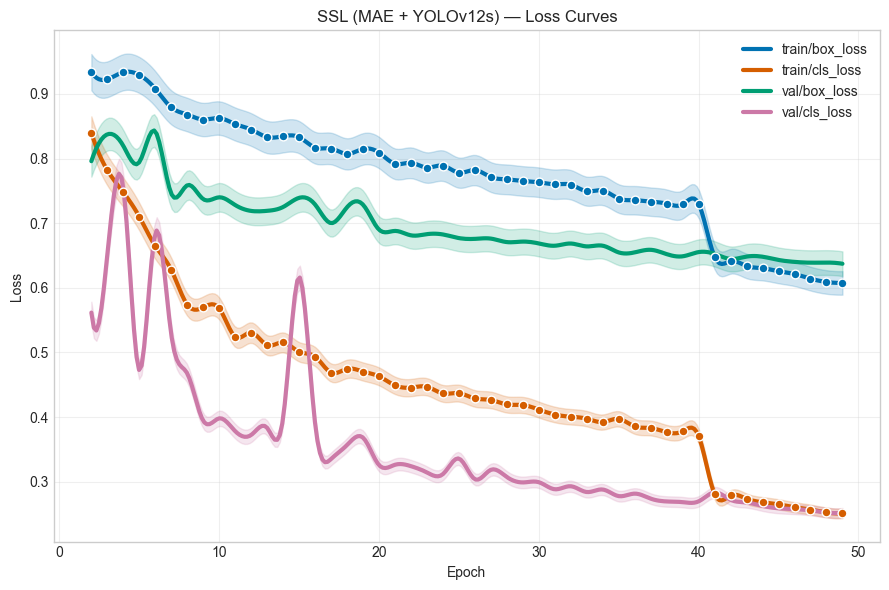

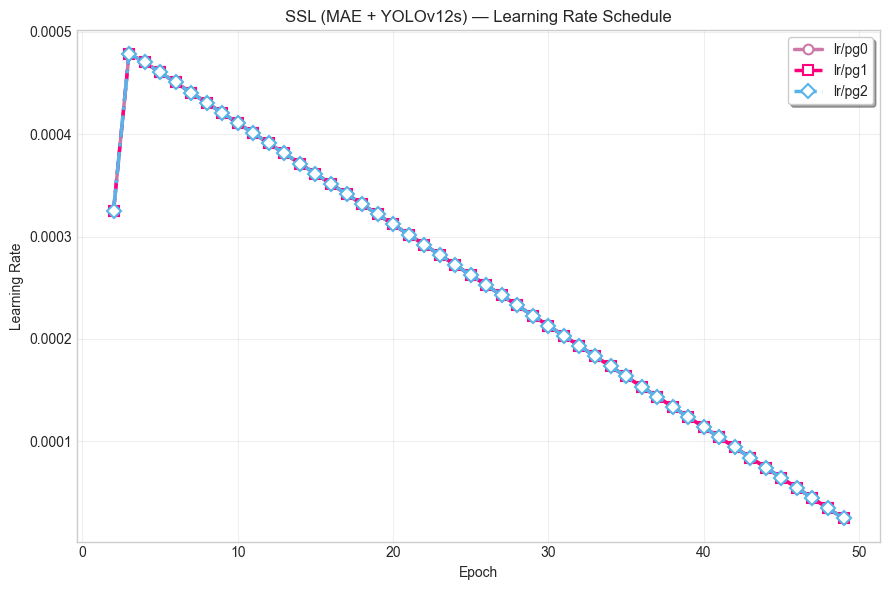

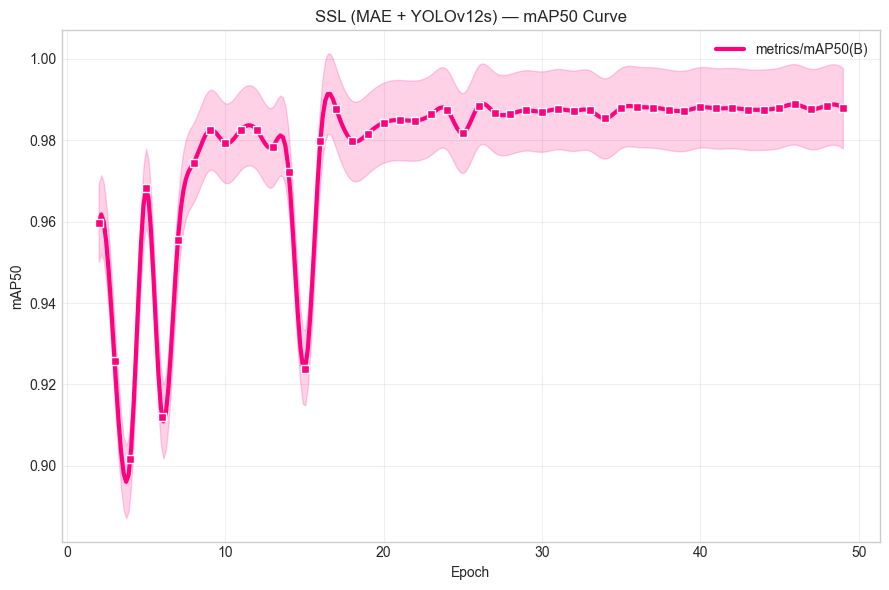

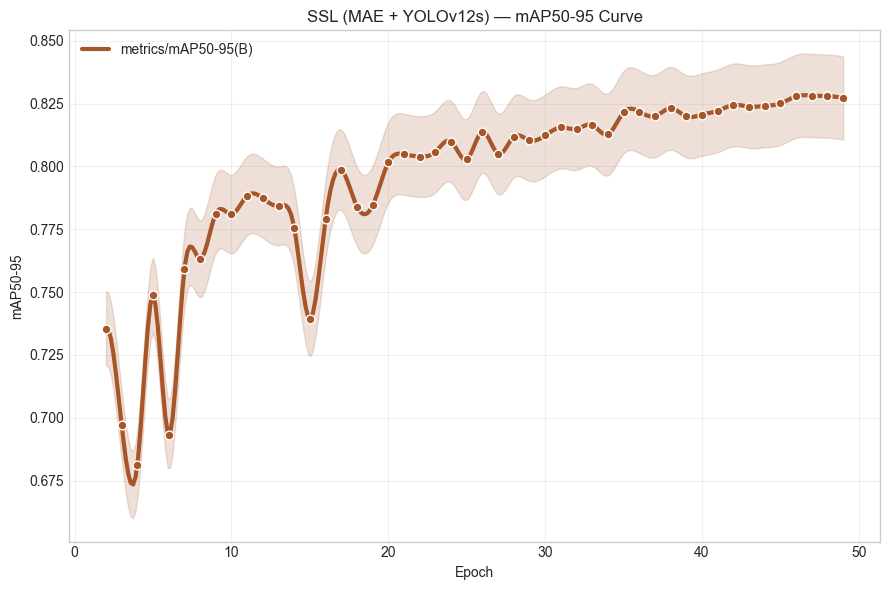

In [15]:
# ============================================================
# YOLOv12s + MAE — Ribbon Spline Curves
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy.interpolate import make_interp_spline
from PIL import Image
from IPython.display import display

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
WORK = Path("/kaggle/working/runs/detect/mae_yolov12s_detector")

results_path = WORK / "results.csv"
if not results_path.exists():
    for root, dirs, files in os.walk("/kaggle/working"):
        if "results.csv" in files:
            results_path = Path(root) / "results.csv"
            break

print("Using results file:", results_path)
df = pd.read_csv(results_path)
df.columns = df.columns.str.strip()
print("\nLoaded columns:", df.columns.tolist(), "\n")

# Remove first and last epoch only if enough rows
if len(df) > 4:
    df_plot = df.iloc[1:-1].reset_index(drop=True)
else:
    df_plot = df.reset_index(drop=True)

print(f"Plotting epochs: {df_plot['epoch'].min()} → {df_plot['epoch'].max()}\n")

# ------------------------------------------------------------
# Show results.png
# ------------------------------------------------------------
results_img = WORK / "results.png"
if results_img.exists():
    img = Image.open(results_img)
    display(img)
else:
    print("results.png not found at:", results_img)

# ------------------------------------------------------------
# Color Palette
# ------------------------------------------------------------
palette = [
    "#0072B2",  # blue
    "#D55E00",  # vermillion
    "#009E73",  # green
    "#CC79A7",  # pink
    "#FF007F",  # neon pink
    "#56B4E9",  # sky blue
    "#A65628",  # brown
]

# ------------------------------------------------------------
# Safe spline — degrades gracefully for small epoch counts
# ------------------------------------------------------------
def safe_spline(x, y):
    n = len(x)
    k = min(3, n - 1)   # k must be < n
    if k < 1:
        return x, y     # single point, nothing to interpolate
    xs = np.linspace(x.min(), x.max(), 300)
    ys = make_interp_spline(x, y, k=k)(xs)
    return xs, ys

def ribbon_spline(ax, x, y, color, label=None, markers=False):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    mask = ~np.isnan(x) & ~np.isnan(y)
    x, y = x[mask], y[mask]
    x, idx = np.unique(x, return_index=True)
    y = y[idx]
    if len(x) < 2:
        ax.plot(x, y, color=color, label=label)
        return
    xs, ys = safe_spline(x, y)
    ax.fill_between(xs, ys * 0.97, ys * 1.03, color=color, alpha=0.18)
    ax.plot(xs, ys, color=color, linewidth=3, label=label)
    if markers:
        ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)


# ============================================================
# LOSS PLOT — Ribbon Spline Curves (Training Loss with 'o' markers)
# ============================================================
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(9, 6))

loss_keys = ["train/box_loss", "train/cls_loss", "val/box_loss", "val/cls_loss"]

for i, col in enumerate(loss_keys):
    if col not in df_plot.columns:
        continue

    color = palette[i % len(palette)]

    # Only add 'o' markers for training loss curves
    if "train" in col:
        x = np.array(df_plot["epoch"])
        y = np.array(df_plot[col])

        if len(x) >= 4:
            xs = np.linspace(x.min(), x.max(), 300)
            spline = make_interp_spline(x, y, k=3)
            ys = spline(xs)
            ax.fill_between(xs, ys * 0.97, ys * 1.03, color=color, alpha=0.18)
            ax.plot(xs, ys, color=color, linewidth=3, label=col)
        else:
            ax.plot(x, y, color=color, linewidth=3, label=col)

        ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)
    else:
        # keep previous ribbon spline without markers
        ribbon_spline(ax, df_plot["epoch"], df_plot[col], color, col)

ax.set_title("SSL (MAE + YOLOv12s) — Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# ============================================================
# LEARNING RATE PLOT — DISTINCT STYLES
# ============================================================
lr_cols = [c for c in df_plot.columns if c.startswith("lr/")]

if lr_cols:
    fig, ax = plt.subplots(figsize=(9, 6))

    # Different line styles for each LR curve
    line_styles = ["-", "--", "-.", ":"]
    markers = ["o", "s", "D", "^"]

    for i, col in enumerate(lr_cols):
        color = palette[(i + 3) % len(palette)]
        style = line_styles[i % len(line_styles)]
        marker = markers[i % len(markers)]

        ax.plot(
            df_plot["epoch"],
            df_plot[col],
            color=color,
            linestyle=style,
            linewidth=2.5,
            marker=marker,
            markersize=7,
            markerfacecolor="white",
            markeredgewidth=1.5,
            label=col
        )

    ax.set_title("SSL (MAE + YOLOv12s) — Learning Rate Schedule")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.legend(frameon=True, shadow=True)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No learning rate columns found.")



# ============================================================
# mAP50 — Ribbon Spline (with 's' markers)
# ============================================================
map50_col = "metrics/mAP50(B)"

if map50_col in df_plot.columns:
    fig, ax = plt.subplots(figsize=(9, 6))

    color = palette[4]

    x = np.array(df_plot["epoch"])
    y = np.array(df_plot[map50_col])

    if len(x) >= 4:
        xs = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        ys = spline(xs)
        ax.fill_between(xs, ys * 0.99, ys * 1.01, color=color, alpha=0.18)
        ax.plot(xs, ys, color=color, linewidth=3, label=map50_col)
    else:
        ax.plot(x, y, color=color, linewidth=3, label=map50_col)

    ax.scatter(x, y, color=color, marker="s", s=40, edgecolor="white", zorder=5)

    ax.set_title("SSL (MAE + YOLOv12s) — mAP50 Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP50")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mAP50 not found.")



# ============================================================
# mAP50-95 — Ribbon Spline (with 'o' markers)
# ============================================================
map5095_col = "metrics/mAP50-95(B)"

if map5095_col in df_plot.columns:
    fig, ax = plt.subplots(figsize=(9, 6))

    color = palette[6]

    x = np.array(df_plot["epoch"])
    y = np.array(df_plot[map5095_col])

    if len(x) >= 4:
        xs = np.linspace(x.min(), x.max(), 300)
        spline = make_interp_spline(x, y, k=3)
        ys = spline(xs)
        ax.fill_between(xs, ys * 0.98, ys * 1.02, color=color, alpha=0.18)
        ax.plot(xs, ys, color=color, linewidth=3, label=map5095_col)
    else:
        ax.plot(x, y, color=color, linewidth=3, label=map5095_col)

    ax.scatter(x, y, color=color, marker="o", s=40, edgecolor="white", zorder=5)

    ax.set_title("SSL (MAE + YOLOv12s) — mAP50-95 Curve")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("mAP50-95")
    ax.grid(alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print("mAP50-95 not found.")




# **10.Evaluation**

In [16]:
import glob
from pathlib import Path

# ── Robustly locate best.pt ───────────────────────────────────────────────
# The training run name increments (mae_yolov12s_detector, mae_yolov12s_detector2, …)
# if a folder already exists.  Instead of hardcoding the suffix, we search for
# the most recently modified best.pt under the working directory.

search_roots = [
    "/kaggle/working/runs",
    "runs",                   # local / Colab working dir
]

candidates = []
for root in search_roots:
    candidates += glob.glob(f"{root}/**/weights/best.pt", recursive=True)

if not candidates:
    raise FileNotFoundError(
        "Could not find any best.pt under runs/.  "
        "Make sure the YOLO training cell (Section 8) completed successfully."
    )

# Pick the most recently written checkpoint
best_pt = Path(max(candidates, key=lambda p: Path(p).stat().st_mtime))
print(f"Using checkpoint: {best_pt}")

# ── Evaluate ──────────────────────────────────────────────────────────────
detector = YOLO(str(best_pt))
results = detector.val(
    data=DATA_YAML,
    imgsz=640,
    batch=64,
    device=0 if torch.cuda.is_available() else "cpu"
)

try:
    mp, mr, map50, map5095 = results.mean_results()
except Exception:
    mp, mr     = float(results.box.mp),    float(results.box.mr)
    map50, map5095 = float(results.box.map50), float(results.box.map)

print("\nValidation metrics")
print(f"  Precision (mP) : {mp:.4f}")
print(f"  Recall    (mR) : {mr:.4f}")
print(f"  mAP@0.50       : {map50:.4f}")
print(f"  mAP@0.50-0.95  : {map5095:.4f}")


Using checkpoint: /kaggle/working/runs/detect/mae_yolov12s_detector-2/weights/best.pt
Ultralytics 8.4.51 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv12s summary (fused): 159 layers, 9,237,072 parameters, 0 gradients, 21.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1413.7±404.5 MB/s, size: 41.3 KB)
val: Scanning /kaggle/working/Non-Seasonal-Vegetable-Detection-3/valid/labels.cache... 717 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 717/717 300.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 12/12 1.4s/it 16.4s
                   all        717       3615      0.985      0.989      0.988      0.829
  Bitter_Gourd_Damaged         49        222      0.986      0.982      0.993      0.852
    Bitter_Gourd_Fresh         52        161      0.972      0.994      0.994      0.896
      Cucumber_Damaged         63        254      0.998          1      0.995      0.814
        Cuc

**Best Pt file**

In [17]:
# Re-use the best_pt path resolved in the Evaluation cell above.
# If you are running this cell standalone, re-run the Evaluation cell first
# so that `best_pt` is defined, or set it manually:
#   best_pt = Path("/kaggle/working/runs/detect/<run_name>/weights/best.pt")

detector = YOLO(str(best_pt))
print(f"Loaded detector from: {best_pt}")


Loaded detector from: /kaggle/working/runs/detect/mae_yolov12s_detector-2/weights/best.pt


In [18]:
results = detector.predict(
    source=f"{ROOT}/test/images",  # same dataset structure
    conf=0.25,
    iou=0.45,
    save=True,
    save_txt=True
)



image 1/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_100_jpg.rf.ab4b4565a78f60f301ca6a30d1ecea1e.jpg: 640x640 4 Bitter_Gourd_Damageds, 20.9ms
image 2/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_105_jpg.rf.55f417bf52243c7099ae25fa814b7058.jpg: 640x640 5 Bitter_Gourd_Damageds, 20.8ms
image 3/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_107_jpg.rf.740770ed4741b89502ea33fb091ac7cb.jpg: 640x640 5 Bitter_Gourd_Damageds, 20.8ms
image 4/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_10_jpg.rf.ecd59a29224212c13b6267bd24864b43.jpg: 640x640 1 Bitter_Gourd_Damaged, 20.8ms
image 5/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/Bitter_Gourd_Damaged_117_jpg.rf.1974f15af88cd46e1fe78505c6082cb8.jpg: 640x640 6 Bitter_Gourd_Damageds, 17.4ms
image 6/721 /kaggle/working/Non-Seasonal-Vegetable-Detection-3/test/images/B

# **11.Vegetable Detection Example Images**

Visualising: Potato_Fresh_88_jpg.rf.6cac05a983de4468ab71696b522ea0c9.jpg
Visualising: Potato_Damaged_158_jpg.rf.0bf990f231b8219354f8cd3eefbaf25c.jpg
Visualising: Multiclass_Vegetable_536_jpg.rf.c34d3d8c9c9df4976045a382bd03166c.jpg
Visualising: Potato_Damaged_97_jpg.rf.26c88bbaf32603c68d3d167c17f5053c.jpg


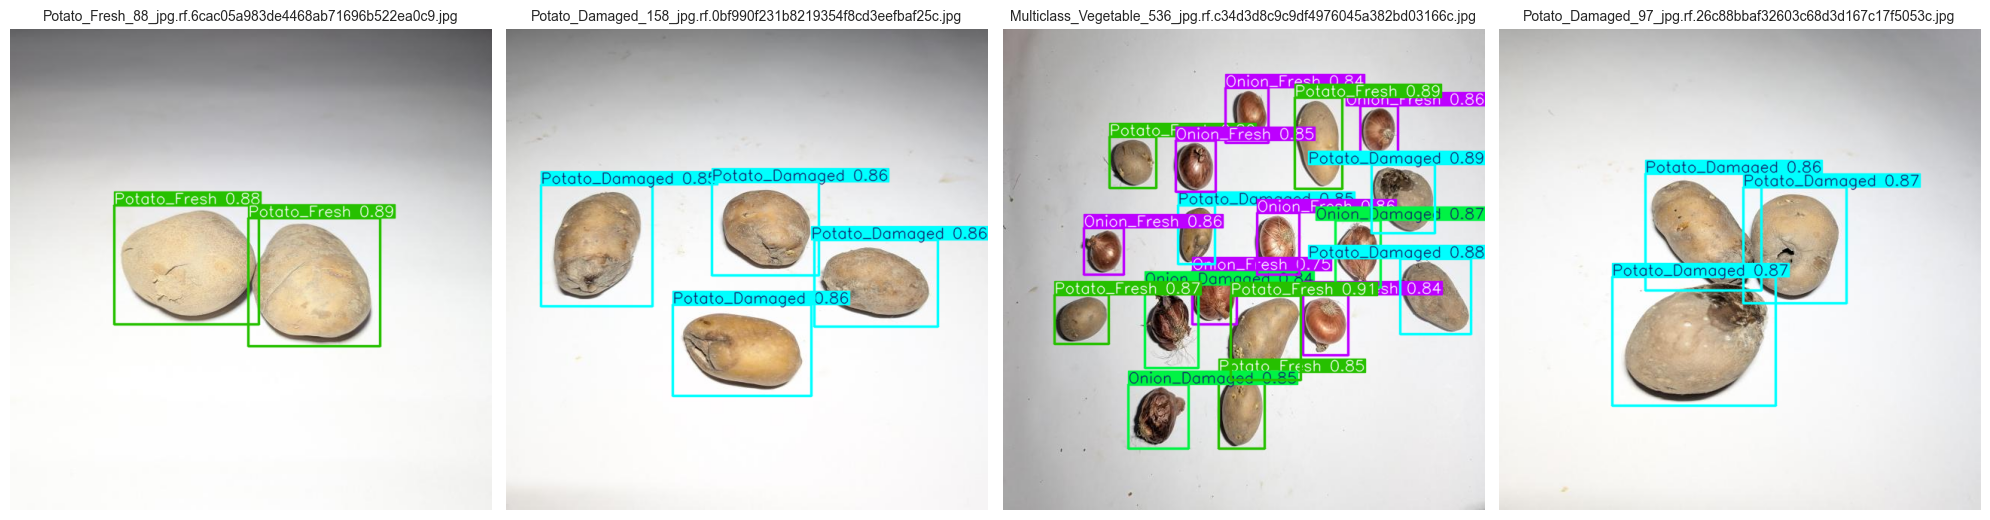

In [19]:
# ============================================================
# SSL (MAE + YOLOv12s) — Sample Output: 4 Random Test Images Side by Side
# ============================================================
import random
import matplotlib.pyplot as plt
from pathlib import Path
%matplotlib inline

# Pick from test or valid images
cands = list(Path(f"{ROOT}/test/images").glob("*.*")) or list(Path(f"{ROOT}/valid/images").glob("*.*"))

if cands:
    imgs = random.sample(cands, min(4, len(cands)))  # pick up to 4 random images
    fig, axes = plt.subplots(1, 4, figsize=(20, 6))
    axes = axes.flatten()

    for ax, img_path in zip(axes, imgs):
        print("Visualising:", img_path.name)
        pred = detector.predict(
            source=str(img_path),
            imgsz=640,
            conf=0.25,
            iou=0.45,
            device=0 if torch.cuda.is_available() else "cpu",
            verbose=False
        )[0]
        ax.imshow(pred.plot()[:, :, ::-1])
        ax.axis("off")
        ax.set_title(img_path.name, fontsize=10)

    # hide unused axes if <4 images
    for ax in axes[len(imgs):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

else:
    print("No images found for visualization.")
